In [2]:
from google.colab import files
uploaded = files.upload()

Saving real_estate_listings.csv to real_estate_listings.csv


In [3]:
import pandas as pd

df = pd.read_csv("real_estate_listings.csv")
df.head()

,Location,Price,Type of House,Land Area,Bedrooms,Toilets,Total Floors,Main Door Direction,Balcony Direction,Legal Documents
0,"Phường 15, Quận Bình Thạnh","4,16 tỷ","Nhà hẻm, ngõ","36 m² (3,2x12,0)",4 phòng,3 WC,2.0,NaN,NaN,Sổ hồng
1,"Xã Tân Kiên, Huyện Bình Chánh",1 tỷ,Nhà mặt tiền,"93,9 m² (5,0x18,8)",3 phòng,2 WC,1.0,NaN,NaN,Sổ hồng
2,"Phường Thạnh Xuân, Quận 12","6,5 tỷ","Nhà hẻm, ngõ","138 m² (8,2x17,0)",3 phòng,3 WC,2.0,NaN,NaN,Sổ hồng
3,"Phường 5, Quận Gò Vấp",23 tỷ,"Nhà hẻm, ngõ","135 m² (5,0x27,0)",21 phòng,21 WC,5.0,Tây Nam,NaN,Sổ hồng
4,"Phường 2, Quận Tân Bình",NaN,"Biệt thự, Villa","100 m² (5,0x20,0)",5 phòng,NaN,NaN,NaN,NaN,Sổ hồng


In [6]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26048 entries, 0 to 26047
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Location             26048 non-null  object 
 1   Price                25026 non-null  object 
 2   Type of House        26048 non-null  object 
 3   Land Area            25993 non-null  object 
 4   Bedrooms             13057 non-null  object 
 5   Toilets              10805 non-null  object 
 6   Total Floors         6011 non-null   float64
 7   Main Door Direction  4639 non-null   object 
 8   Balcony Direction    2596 non-null   object 
 9   Legal Documents      26048 non-null  object 
dtypes: float64(1), object(9)
memory usage: 2.0+ MB
None
                        Location    Price    Type of House  \
0     Phường 15, Quận Bình Thạnh  4,16 tỷ     Nhà hẻm, ngõ   
1  Xã Tân Kiên, Huyện Bình Chánh     1 tỷ     Nhà mặt tiền   
2     Phường Thạnh Xuân, Quận 12   6,5 tỷ     Nh

Clean cột PRICE

In [10]:
import re

def clean_price(x):
    if pd.isna(x):
        return None

    x = str(x).lower()

    # Xóa ký tự thừa
    x = x.replace(",", ".")
    x = re.sub(r"\s+", " ", x)  # xóa khoảng trắng dư

    try:
        # Trường hợp có cả tỷ và triệu (vd: 6 tỷ 500 triệu)
        if "tỷ" in x and "triệu" in x:
            parts = re.findall(r"[\d.]+", x)
            if len(parts) >= 2:
                ty = float(parts[0])
                trieu = float(parts[1])
                return ty * 1e9 + trieu * 1e6

        elif "tỷ" in x:
            num = re.findall(r"[\d.]+", x)[0]
            return float(num) * 1e9

        elif "triệu" in x:
            num = re.findall(r"[\d.]+", x)[0]
            return float(num) * 1e6

        else:
            return None
    except:
        return None

In [11]:
df["price_vnd"] = df["Price"].apply(clean_price)

In [13]:
df = df.dropna(subset=["price_vnd"])

In [14]:
df[["Price", "price_vnd"]].head(10)

,Price,price_vnd
0,"4,16 tỷ",4.160000e+09
1,1 tỷ,1.000000e+09
2,"6,5 tỷ",6.500000e+09
3,23 tỷ,2.300000e+10
5,38 tỷ,3.800000e+10
6,6 tỷ 500 triệu,6.500000e+09
7,"43,5 tỷ",4.350000e+10
9,19 tỷ,1.900000e+10
10,"9,6 tỷ",9.600000e+09
11,"1,49 tỷ",1.490000e+09


Clean diện tích

In [16]:
import re

def clean_area(x):
    if pd.isna(x):
        return None

    x = str(x)

    # Lấy số đầu tiên trong chuỗi
    nums = re.findall(r"[\d.,]+", x)

    if not nums:
        return None

    num = nums[0]

    # Chuẩn hóa:
    num = num.replace(",", ".")

    # Nếu có nhiều dấu chấm → giữ lại dấu chấm cuối
    if num.count(".") > 1:
        parts = num.split(".")
        num = "".join(parts[:-1]) + "." + parts[-1]

    try:
        return float(num)
    except:
        return None

In [17]:
df["area"] = df["Land Area"].apply(clean_area)

In [18]:
df[["Land Area", "area"]].head(10)

,Land Area,area
0,"36 m² (3,2x12,0)",36.0
1,"93,9 m² (5,0x18,8)",93.9
2,"138 m² (8,2x17,0)",138.0
3,"135 m² (5,0x27,0)",135.0
5,"900 m² (12,0x50,0)",900.0
6,"48 m² (4,0x12,0)",48.0
7,"160 m² (8,0x20,0)",160.0
9,"120 m² (8,0x15,0)",120.0
10,"100,1 m² (5,0x20,2)",100.1
11,"11 m² (3,0x4,0)",11.0


Tính VND/m2

In [19]:
df["price_per_m2"] = df["price_vnd"] / df["area"]

In [20]:
df[["price_vnd", "area", "price_per_m2"]].head()

,price_vnd,area,price_per_m2
0,4.160000e+09,36.0,1.155556e+08
1,1.000000e+09,93.9,1.064963e+07
2,6.500000e+09,138.0,4.710145e+07
3,2.300000e+10,135.0,1.703704e+08
5,3.800000e+10,900.0,4.222222e+07


Lấy Quận

In [21]:
def extract_district(loc):
    if pd.isna(loc):
        return None
    parts = loc.split(",")
    for p in parts:
        if "Quận" in p or "Huyện" in p:
            return p.strip()
    return None

df["district"] = df["Location"].apply(extract_district)

In [22]:
df[["Location", "district"]].head()

,Location,district
0,"Phường 15, Quận Bình Thạnh",Quận Bình Thạnh
1,"Xã Tân Kiên, Huyện Bình Chánh",Huyện Bình Chánh
2,"Phường Thạnh Xuân, Quận 12",Quận 12
3,"Phường 5, Quận Gò Vấp",Quận Gò Vấp
5,"Xã Phạm Văn Hai, Huyện Bình Chánh",Huyện Bình Chánh


Tạo ROI

In [23]:
import numpy as np

df["purchase_price"] = df["price_vnd"] * np.random.uniform(0.8, 0.95, len(df))
df["current_price"] = df["price_vnd"]

df["ROI"] = (df["current_price"] - df["purchase_price"]) / df["purchase_price"]

In [24]:
df = df.dropna(subset=["price_vnd", "area", "district"])
df = df[df["area"] > 0]

In [25]:
print("Tổng tài sản:", df["current_price"].sum())
print("ROI trung bình:", df["ROI"].mean())

Tổng tài sản: 160534635000000.0
ROI trung bình: 0.14574777175507286


Vẽ biểu đồ Roi theo quận

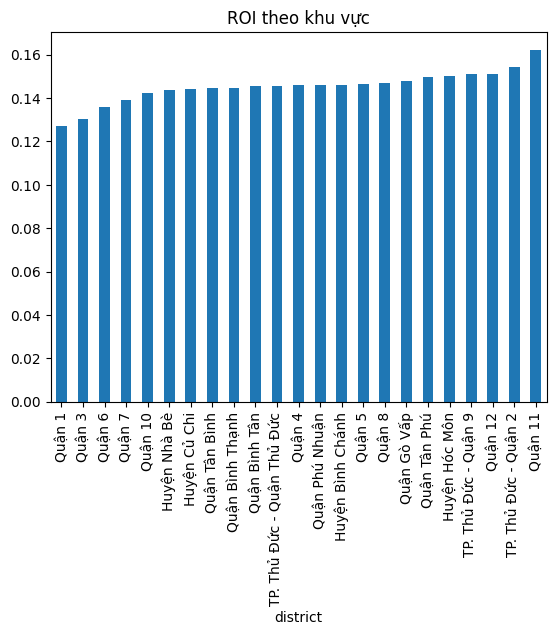

In [26]:
import matplotlib.pyplot as plt

df.groupby("district")["ROI"].mean().sort_values().plot(kind="bar")
plt.title("ROI theo khu vực")
plt.show()

In [27]:
cols = ["district", "price_vnd", "area", "price_per_m2", "ROI"]
df[cols].head()

,district,price_vnd,area,price_per_m2,ROI
0,Quận Bình Thạnh,4.160000e+09,36.0,1.155556e+08,0.122625
1,Huyện Bình Chánh,1.000000e+09,93.9,1.064963e+07,0.112596
2,Quận 12,6.500000e+09,138.0,4.710145e+07,0.069988
3,Quận Gò Vấp,2.300000e+10,135.0,1.703704e+08,0.111655
5,Huyện Bình Chánh,3.800000e+10,900.0,4.222222e+07,0.138406


TÍNH KPI CHO CEO

In [28]:
print("Tổng tài sản:", df["price_vnd"].sum())
print("ROI trung bình:", df["ROI"].mean())
print("Giá trung bình / m2:", df["price_per_m2"].mean())

Tổng tài sản: 160534635000000.0
ROI trung bình: 0.14574777175507286
Giá trung bình / m2: 103798604.1966992


ROI theo khu

In [29]:
roi_by_district = df.groupby("district")["ROI"].mean().sort_values(ascending=False)
print(roi_by_district)

district
Quận 11                       0.162277
TP. Thủ Đức - Quận 2          0.154289
Quận 12                       0.151183
TP. Thủ Đức - Quận 9          0.151065
Huyện Hóc Môn                 0.150132
Quận Tân Phú                  0.149796
Quận Gò Vấp                   0.147685
Quận 8                        0.146776
Quận 5                        0.146590
Huyện Bình Chánh              0.145978
Quận Phú Nhuận                0.145943
Quận 4                        0.145867
TP. Thủ Đức - Quận Thủ Đức    0.145655
Quận Bình Tân                 0.145634
Quận Bình Thạnh               0.144749
Quận Tân Bình                 0.144550
Huyện Củ Chi                  0.144151
Huyện Nhà Bè                  0.143857
Quận 10                       0.142393
Quận 7                        0.139014
Quận 6                        0.135875
Quận 3                        0.130488
Quận 1                        0.126975
Name: ROI, dtype: float64


Giá theo khu

In [30]:
price_m2_by_district = df.groupby("district")["price_per_m2"].mean().sort_values(ascending=False)
print(price_m2_by_district)

district
Quận 1                        5.369520e+08
Huyện Bình Chánh              3.927583e+08
Quận 5                        3.437876e+08
Quận 3                        2.369202e+08
Quận 10                       2.021578e+08
Quận Bình Thạnh               1.980620e+08
Quận 6                        1.729724e+08
Quận 7                        1.519719e+08
Quận 11                       1.342663e+08
TP. Thủ Đức - Quận 2          1.319468e+08
Quận Tân Bình                 1.166243e+08
Quận 8                        1.152454e+08
Quận Tân Phú                  1.147153e+08
Quận Gò Vấp                   1.081101e+08
Quận Phú Nhuận                9.026848e+07
TP. Thủ Đức - Quận Thủ Đức    7.127407e+07
Quận Bình Tân                 6.870012e+07
Quận 12                       5.425433e+07
Quận 4                        5.100923e+07
TP. Thủ Đức - Quận 9          4.969005e+07
Huyện Nhà Bè                  4.535858e+07
Huyện Hóc Môn                 4.477799e+07
Huyện Củ Chi                  8.744082e+06
Na

Bar chart – ROI

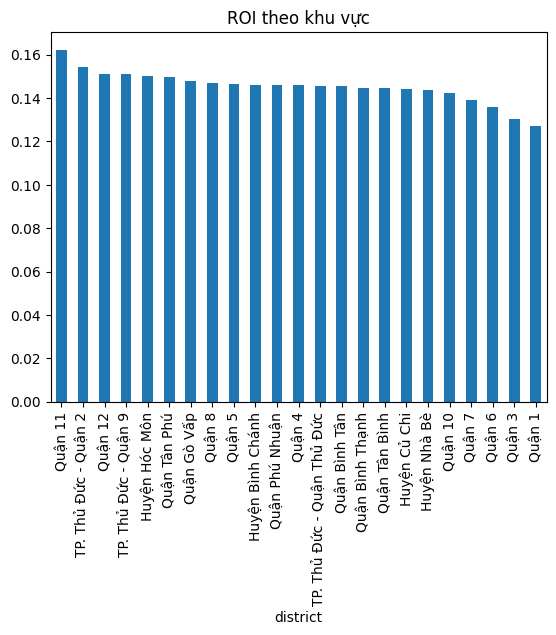

In [31]:
import matplotlib.pyplot as plt

roi_by_district.plot(kind="bar")
plt.title("ROI theo khu vực")
plt.show()

Pie chart – vốn

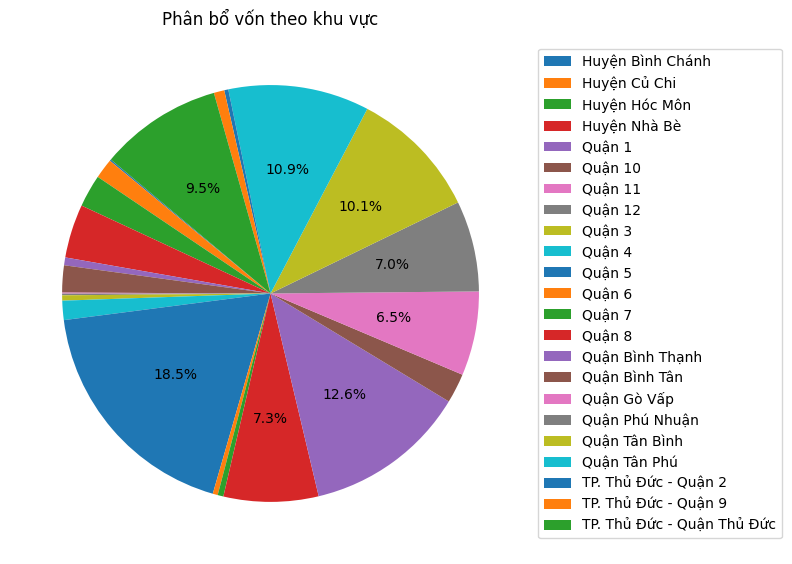

In [36]:
import matplotlib.pyplot as plt

data = df.groupby("district")["price_vnd"].sum()

def autopct_func(pct):
    return ('%1.1f%%' % pct) if pct > 5 else ''   # ❗ chỉ hiện >5%

plt.figure(figsize=(8,8))

plt.pie(
    data,
    labels=None,
    autopct=autopct_func,
    startangle=140
)

plt.legend(
    data.index,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Phân bổ vốn theo khu vực")
plt.tight_layout()
plt.show()

Line chart – xu hướng

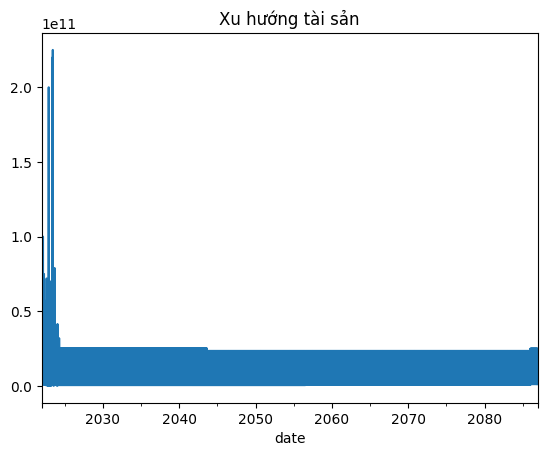

In [33]:
df["date"] = pd.date_range(start="2022-01-01", periods=len(df))

df.sort_values("date").set_index("date")["price_vnd"].plot()
plt.title("Xu hướng tài sản")
plt.show()

Top 3 khu nên đầu tư

In [34]:
score = df.groupby("district").agg({
    "ROI": "mean",
    "price_per_m2": "mean"
})

score["score"] = score["ROI"] / score["price_per_m2"]
print(score.sort_values("score", ascending=False).head(3))

                    ROI  price_per_m2         score
district                                           
Huyện Củ Chi   0.144151  8.744082e+06  1.648555e-08
Huyện Hóc Môn  0.150132  4.477799e+07  3.352808e-09
Huyện Nhà Bè   0.143857  4.535858e+07  3.171547e-09
